c:\Users\hitar\Desktop\Internship\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\hitar\Desktop\Internship\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\hitar\Desktop\Internship\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\hitar\Desktop\Internship\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was


MODEL COMPARISON

                 Model  Test Accuracy  CV Accuracy
0  Logistic Regression       1.000000     0.973333
1                  SVM       0.966667     0.960000
2        Random Forest       0.966667     0.960000
3                  MLP       0.933333     0.953333

BEST MODEL:
Logistic Regression

CLASSIFICATION REPORT

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



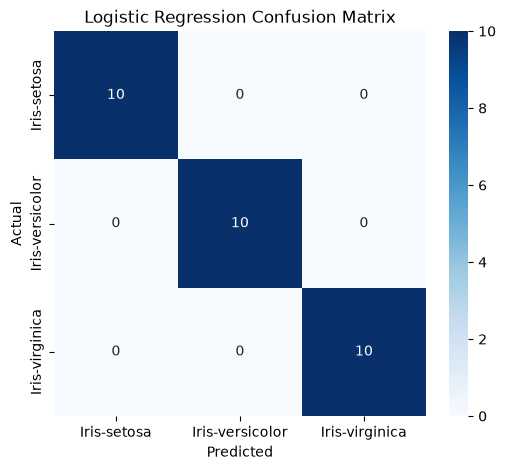

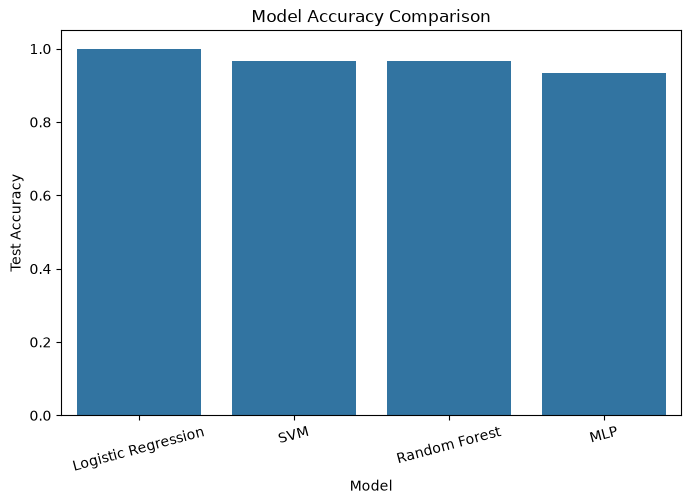

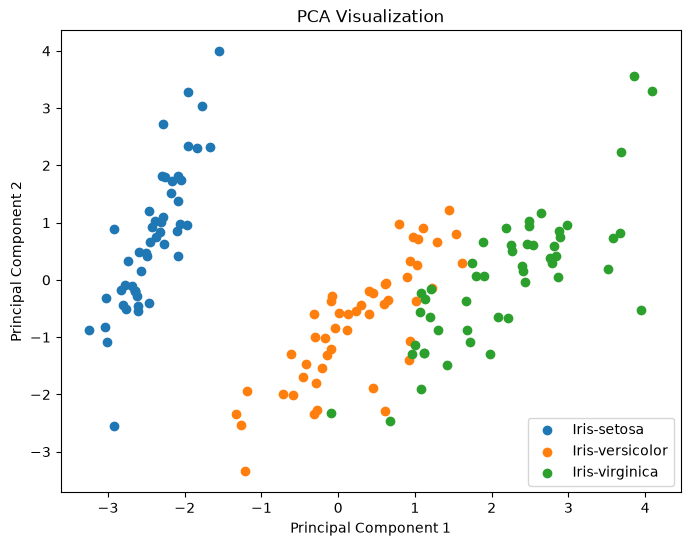

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.inspection import permutation_importance

df = pd.read_csv("Iris.csv")

if "Id" in df.columns:
    df = df.drop("Id", axis=1)

df["PetalArea"] = df["PetalLengthCm"] * df["PetalWidthCm"]
df["SepalArea"] = df["SepalLengthCm"] * df["SepalWidthCm"]

X = df.drop("Species", axis=1)
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(probability=True))
    ]),

    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(random_state=42))
    ]),

    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=1000,
            random_state=42
        ))
    ])
}

param_grids = {
    "Logistic Regression": {
        "clf__C": [0.1, 1, 10, 100]
    },

    "SVM": {
        "clf__C": [0.1, 1, 10, 100],
        "clf__gamma": ["scale", 0.1, 0.01]
    },

    "Random Forest": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 5, 10, None]
    },

    "MLP": {
        "clf__hidden_layer_sizes": [(64, 32), (128, 64)],
        "clf__alpha": [0.0001, 0.001, 0.01]
    }
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []
best_models = {}

for name, model in models.items():

    grid = GridSearchCV(
        model,
        param_grids[name],
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    best_models[name] = best_model

    y_pred = best_model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    cv_score = cross_val_score(
        best_model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    ).mean()

    results.append([
        name,
        accuracy,
        cv_score
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Test Accuracy",
        "CV Accuracy"
    ]
)

results_df = results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

print("\nMODEL COMPARISON\n")
print(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

print("\nBEST MODEL:")
print(best_model_name)

y_pred = best_model.predict(X_test)

print("\nCLASSIFICATION REPORT\n")
print(
    classification_report(
        y_test,
        y_pred
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)

plt.title(f"{best_model_name} Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Test Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.show()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

for species in np.unique(y):

    mask = y == species

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=species
    )

plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

if best_model_name == "Random Forest":

    importance = permutation_importance(
        best_model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42
    )

    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance.importances_mean
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature"
    )

    plt.title("Feature Importance")
    plt.show()

    rf = best_model.named_steps["clf"]

    explainer = shap.TreeExplainer(rf)

    shap_values = explainer.shap_values(X_test)

    shap.summary_plot(
        shap_values,
        X_test,
        feature_names=X.columns
    )